In [25]:
import pandas as pd
df = pd.read_csv("http://114.207.245.181:13000/csv/citrus01.csv")
df.head(5)

,name,diameter,weight,red,green,blue
0,orange,2.96,86.76,172,85,2
1,orange,3.91,88.05,166,78,3
2,orange,4.42,95.17,156,81,2
3,orange,4.47,95.60,163,81,4
4,orange,4.48,95.76,161,72,9


In [26]:
df.dtypes

name         object
diameter    float64
weight      float64
red           int64
green         int64
blue          int64
dtype: object

In [27]:
df['name'].value_counts()

name
orange        5000
grapefruit    5000
Name: count, dtype: int64

In [28]:
df.columns

Index(['name', 'diameter', 'weight', 'red', 'green', 'blue'], dtype='object')

In [29]:
t1 = dict(zip(df.columns, ['이름', '직경', '무게', '빨강', '초록', '파랑']))
t1

{'name': '이름',
 'diameter': '직경',
 'weight': '무게',
 'red': '빨강',
 'green': '초록',
 'blue': '파랑'}

In [30]:
df1 = df.rename(columns=t1)
df1

,이름,직경,무게,빨강,초록,파랑
0,orange,2.96,86.76,172,85,2
1,orange,3.91,88.05,166,78,3
2,orange,4.42,95.17,156,81,2
3,orange,4.47,95.60,163,81,4
4,orange,4.48,95.76,161,72,9
...,...,...,...,...,...,...
9995,grapefruit,15.35,253.89,149,77,20
9996,grapefruit,15.41,254.67,148,68,7
9997,grapefruit,15.59,256.50,168,82,20
9998,grapefruit,15.92,260.14,142,72,11


In [ ]:
df1['이름'] = df1['이름'].map({'orange': 0, 'grapefruit': 1})

In [ ]:
df1.head(5)

,이름,직경,무게,빨강,초록,파랑
0,0,2.96,86.76,172,85,2
1,0,3.91,88.05,166,78,3
2,0,4.42,95.17,156,81,2
3,0,4.47,95.60,163,81,4
4,0,4.48,95.76,161,72,9


In [40]:
df1.tail(5)

,이름,직경,무게,빨강,초록,파랑
9995,1,15.35,253.89,149,77,20
9996,1,15.41,254.67,148,68,7
9997,1,15.59,256.50,168,82,20
9998,1,15.92,260.14,142,72,11
9999,1,16.45,261.51,152,74,2


---

In [32]:
x = df1[['직경', '무게', '빨강', '초록', '파랑']].values
y = df1['이름'].values
x.shape, y.shape

((10000, 5), (10000,))

In [33]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=123, train_size=0.8)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((8000, 5), (2000, 5), (8000,), (2000,))

In [34]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=1000)
model.fit(x_train, y_train)

,n_estimators,1000
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
model.score(x_train, y_train), model.score(x_test, y_test)

(1.0, 0.9585)

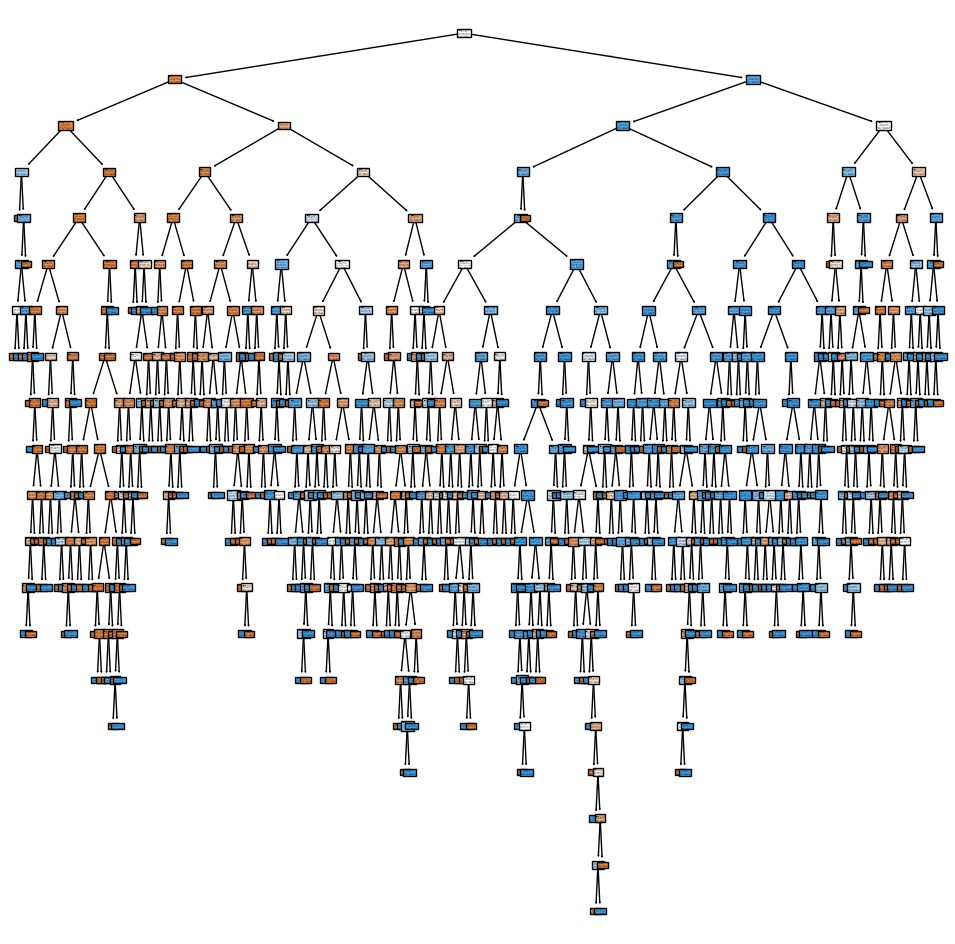

In [ ]:
import matplotlib.pyplot as plt
from seaborn_cjk import patch
from sklearn import tree

patch() 

fn = ['직경', '무게', '빨강', '초록', '파랑'] # 특정정보
cn = ['orange', 'grapefruit'] # 타겟정보

plt.figure(figsize=(12,12))
tree.plot_tree(model.estimators_[0], filled=True, feature_names=fn, class_names=cn)
plt.show()

In [37]:
model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 1000,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

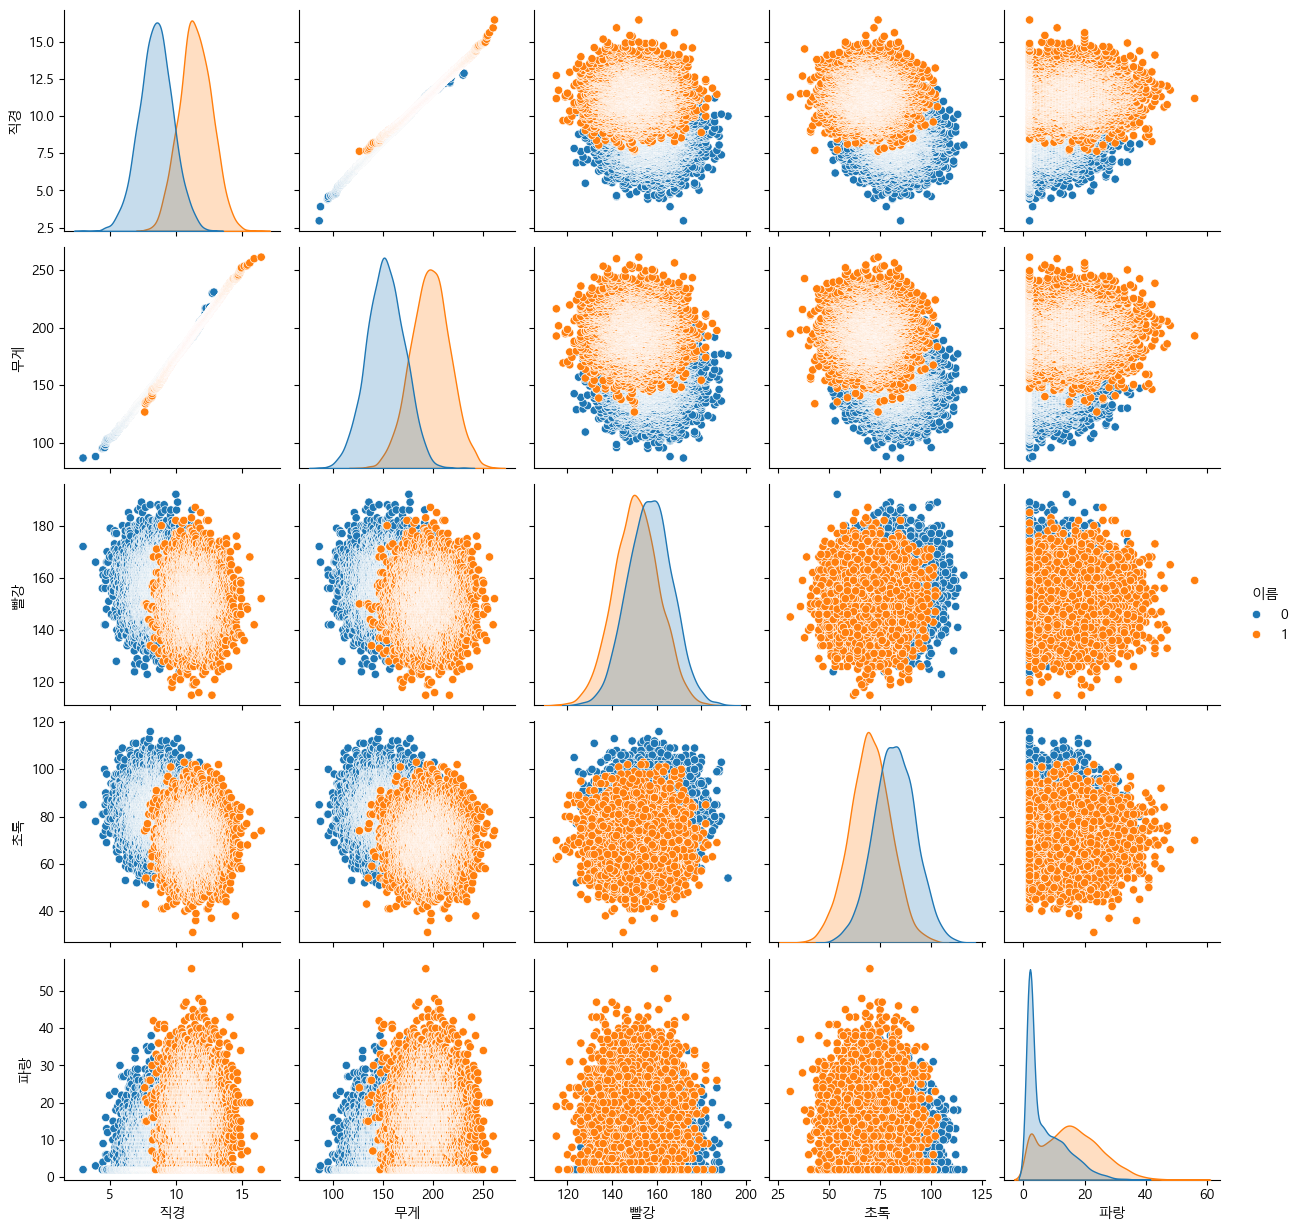

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn_cjk import patch
patch()

sns.pairplot(data=df1, hue='이름')
plt.show()

In [ ]:
# 그리드 서치
from sklearn.model_selection import GridSearchCV

param_grid = {
    #'n_estimators': [100, 500, 1000], too much cpu
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'max_features': [None, 'sqrt', 'log2'],
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=123),
    param_grid=param_grid,
    cv = 5, # 교차검증 5분할후에 1 2 3 4 5
    n_jobs = -1,
    verbose=2
)

grid_search.fit(x_train, y_train)
grid_search.best_params_, grid_search.best_estimator_

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


KeyboardInterrupt: 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model_with_grid_search = RandomForestClassifier(max_features=None, min_samples_split=5, random_state=123, n_estimators=1000)
model_with_grid_search.fit(x_train, y_train)

,n_estimators,1000
,criterion,'gini'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
model_with_grid_search.score(x_train, y_train), model.score(x_test, y_test)

(0.998, 0.9585)

In [81]:
# jackpot 0.9645 is the highest score for x_test, y_test
from sklearn.ensemble import RandomForestClassifier

model_with_log2 = RandomForestClassifier(
    max_features=None, 
    random_state=123, 
    n_estimators=341
)
model_with_log2.fit(x_train, y_train)
model_with_log2.score(x_train, y_train), model_with_log2.score(x_test, y_test)

(1.0, 0.964)